In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [20]:
df = pd.read_csv("data/cleaned_data.csv")
print(df.shape)
df.head()

(1000, 11)


,patient_name,age,gender,condition,medication,visit_date,cholesterol,systolic,diastolic,visit_year,visit_month
0,david lee,25,other,Heart Disease,METFORMIN,2020-01-15,200.0,140.0,90.0,2020.0,1.0
1,emily davis,35,male,Diabetes,NONE,NaN,200.0,120.0,80.0,2020.0,1.0
2,laura martinez,35,other,Asthma,METFORMIN,NaN,160.0,110.0,70.0,2020.0,1.0
3,michael wilson,35,male,Diabetes,ALBUTEROL,2020-01-15,180.0,110.0,70.0,2020.0,1.0
4,david lee,35,female,Asthma,NONE,NaN,180.0,110.0,70.0,2020.0,1.0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_name  1000 non-null   object 
 1   age           1000 non-null   int64  
 2   gender        1000 non-null   object 
 3   condition     1000 non-null   object 
 4   medication    1000 non-null   object 
 5   visit_date    183 non-null    object 
 6   cholesterol   1000 non-null   float64
 7   systolic      1000 non-null   float64
 8   diastolic     1000 non-null   float64
 9   visit_year    1000 non-null   float64
 10  visit_month   1000 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 86.1+ KB


In [19]:
df.head()

,patient_name,age,gender,condition,medication,visit_date,cholesterol,systolic,diastolic,visit_year,visit_month
0,david lee,25,other,Heart Disease,METFORMIN,2020-01-15,200.0,140.0,90.0,2020.0,1.0
1,emily davis,35,male,Diabetes,NONE,NaN,200.0,120.0,80.0,2020.0,1.0
2,laura martinez,35,other,Asthma,METFORMIN,NaN,160.0,110.0,70.0,2020.0,1.0
3,michael wilson,35,male,Diabetes,ALBUTEROL,2020-01-15,180.0,110.0,70.0,2020.0,1.0
4,david lee,35,female,Asthma,NONE,NaN,180.0,110.0,70.0,2020.0,1.0


In [5]:
df_encoded = df.copy()
df_encoded = df_encoded.drop(columns=['patient_name'])


if 'visit_date' in df_encoded.columns:
    df_encoded['visit_date'] = pd.to_datetime(df_encoded['visit_date'])
    df_encoded['visit_year']  = df_encoded['visit_date'].dt.year
    df_encoded['visit_month'] = df_encoded['visit_date'].dt.month
    df_encoded = df_encoded.drop(columns=['visit_date'])

le_gender = LabelEncoder()
le_medication = LabelEncoder()
df_encoded['gender']     = le_gender.fit_transform(df_encoded['gender'])
df_encoded['medication'] = le_medication.fit_transform(df_encoded['medication'])

print("Columns now:", df_encoded.columns.tolist())
print("Dtypes:\n", df_encoded.dtypes)
df_encoded.head()

Columns now: ['age', 'gender', 'condition', 'medication', 'cholesterol', 'systolic', 'diastolic', 'visit_year', 'visit_month']
Dtypes:
 age              int64
gender           int64
condition       object
medication       int64
cholesterol    float64
systolic       float64
diastolic      float64
visit_year     float64
visit_month    float64
dtype: object


,age,gender,condition,medication,cholesterol,systolic,diastolic,visit_year,visit_month
0,25,2,Heart Disease,3,200.0,140.0,90.0,2020.0,1.0
1,35,1,Diabetes,4,200.0,120.0,80.0,NaN,NaN
2,35,2,Asthma,3,160.0,110.0,70.0,NaN,NaN
3,35,1,Diabetes,0,180.0,110.0,70.0,2020.0,1.0
4,35,0,Asthma,4,180.0,110.0,70.0,NaN,NaN


In [6]:

print("NaNs per column:")
print(df_encoded.isnull().sum())

df_encoded = df_encoded.fillna(df_encoded.median(numeric_only=True))


print("\nAfter fix - Any NaN?", df_encoded.isnull().any().any())

NaNs per column:
age              0
gender           0
condition        0
medication       0
cholesterol      0
systolic         0
diastolic        0
visit_year     817
visit_month    817
dtype: int64

After fix - Any NaN? False


In [7]:
X = df_encoded.drop(columns=['condition'])
y = df_encoded['condition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print("Train:", len(X_train), "| Test:", len(X_test))
print("Classes:", y.unique())

Train: 800 | Test: 200
Classes: ['Heart Disease' 'Diabetes' 'Asthma' 'Hypertension']


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Naive Bayes

In [9]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
nb_pred = nb.predict(X_test_scaled)

print("=== Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred, zero_division=0))

=== Naive Bayes ===
Accuracy: 0.355
               precision    recall  f1-score   support

       Asthma       0.39      0.80      0.52        81
     Diabetes       0.00      0.00      0.00        45
Heart Disease       0.19      0.15      0.16        41
 Hypertension       0.00      0.00      0.00        33

     accuracy                           0.35       200
    macro avg       0.14      0.24      0.17       200
 weighted avg       0.20      0.35      0.25       200



In [10]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("y_train shape:", y_train.shape)
print("y_train values:", y_train.values)
print("X_train_scaled dtype:", X_train_scaled.dtype)
print("Any NaN in X?", np.isnan(X_train_scaled).any())

X_train_scaled shape: (800, 8)
y_train shape: (800,)
y_train values: ['Hypertension' 'Asthma' 'Asthma' 'Asthma' 'Heart Disease' 'Diabetes'
 'Asthma' 'Hypertension' 'Heart Disease' 'Asthma' 'Asthma' 'Asthma'
 'Asthma' 'Asthma' 'Asthma' 'Diabetes' 'Heart Disease' 'Asthma' 'Diabetes'
 'Asthma' 'Diabetes' 'Asthma' 'Diabetes' 'Heart Disease' 'Heart Disease'
 'Asthma' 'Asthma' 'Diabetes' 'Hypertension' 'Heart Disease'
 'Hypertension' 'Asthma' 'Heart Disease' 'Hypertension' 'Diabetes'
 'Asthma' 'Heart Disease' 'Asthma' 'Heart Disease' 'Asthma' 'Diabetes'
 'Diabetes' 'Heart Disease' 'Diabetes' 'Diabetes' 'Asthma' 'Heart Disease'
 'Asthma' 'Heart Disease' 'Heart Disease' 'Heart Disease' 'Hypertension'
 'Heart Disease' 'Diabetes' 'Asthma' 'Asthma' 'Diabetes' 'Diabetes'
 'Asthma' 'Hypertension' 'Hypertension' 'Hypertension' 'Heart Disease'
 'Diabetes' 'Asthma' 'Hypertension' 'Heart Disease' 'Asthma'
 'Hypertension' 'Asthma' 'Asthma' 'Asthma' 'Hypertension' 'Diabetes'
 'Diabetes' 'Asthma' 'Diabete

Random Forest

In [25]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

=== Random Forest ===
Accuracy: 0.31
               precision    recall  f1-score   support

       Asthma       0.43      0.52      0.47        81
     Diabetes       0.24      0.18      0.20        45
Heart Disease       0.16      0.15      0.15        41
 Hypertension       0.19      0.18      0.18        33

     accuracy                           0.31       200
    macro avg       0.25      0.26      0.25       200
 weighted avg       0.29      0.31      0.30       200



SVM

In [26]:
svm = LinearSVC(random_state=42, max_iter=2000)
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)

print("=== SVM ===")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred, zero_division=0))

=== SVM ===
Accuracy: 0.4
               precision    recall  f1-score   support

       Asthma       0.40      0.99      0.57        81
     Diabetes       0.00      0.00      0.00        45
Heart Disease       0.00      0.00      0.00        41
 Hypertension       0.00      0.00      0.00        33

     accuracy                           0.40       200
    macro avg       0.10      0.25      0.14       200
 weighted avg       0.16      0.40      0.23       200



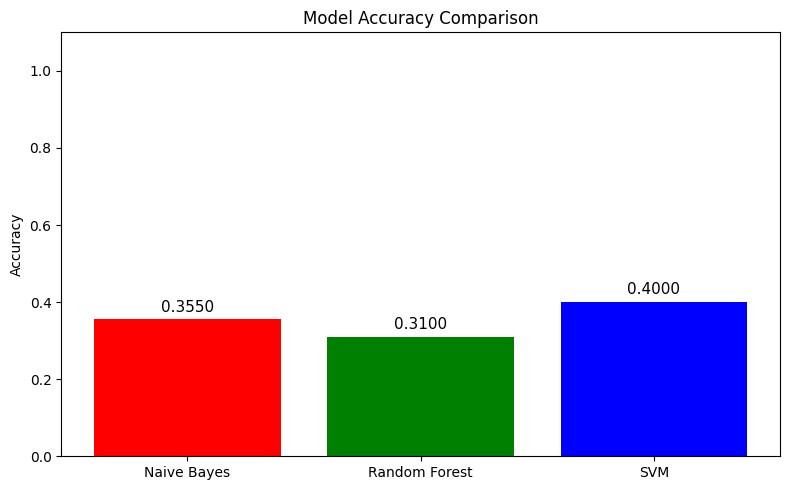

In [32]:
models     = ['Naive Bayes', 'Random Forest', 'SVM']
accuracies = [accuracy_score(y_test, nb_pred),
              accuracy_score(y_test, rf_pred),
              accuracy_score(y_test, svm_pred)]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['red', 'green', 'blue'])
plt.ylim(0, 1.1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{acc:.4f}", ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('data/model_comparison.png')
plt.show()

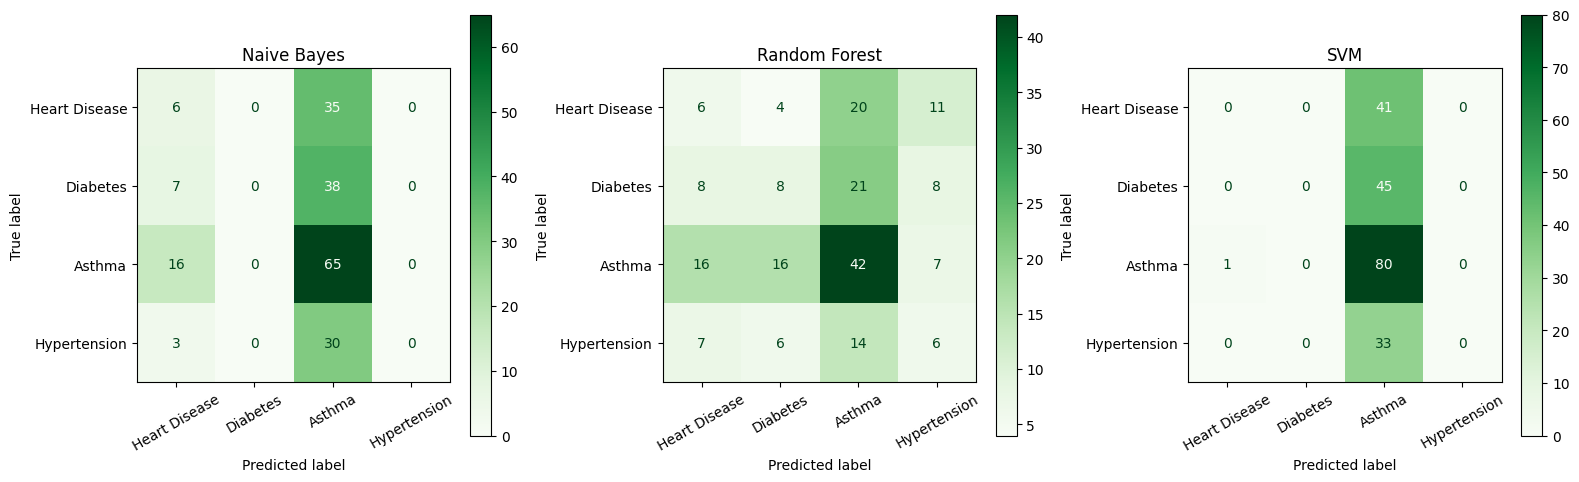

In [31]:
labels = list(y.unique())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, pred, name in zip(axes,
                           [nb_pred, rf_pred, svm_pred],
                           ['Naive Bayes', 'Random Forest', 'SVM']):
    cm = confusion_matrix(y_test, pred, labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap='Greens')
    ax.set_title(name)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('data/confusion_matrices.png', bbox_inches='tight')
plt.show()

In [29]:
results_df = pd.DataFrame({
    'actual'       : y_test.values,
    'nb_predicted' : nb_pred,
    'rf_predicted' : rf_pred,
    'svm_predicted': svm_pred
})
results_df.to_csv('data/classification_results.csv', index=False)
results_df

,actual,nb_predicted,rf_predicted,svm_predicted
0,Diabetes,Heart Disease,Asthma,Asthma
1,Diabetes,Asthma,Asthma,Asthma
2,Asthma,Asthma,Asthma,Asthma
3,Asthma,Asthma,Heart Disease,Asthma
4,Asthma,Asthma,Asthma,Asthma
...,...,...,...,...
195,Heart Disease,Asthma,Diabetes,Asthma
196,Hypertension,Asthma,Asthma,Asthma
197,Diabetes,Asthma,Asthma,Asthma
198,Diabetes,Heart Disease,Asthma,Asthma


In [30]:
def predict_patient(age, gender, medication, cholesterol, systolic, diastolic, visit_year, visit_month):
    g = le_gender.transform([gender])[0]
    m = le_medication.transform([medication])[0]
    
    
    data = pd.DataFrame([[age, g, m, cholesterol, systolic, diastolic, visit_year, visit_month]],
                        columns=X.columns)
    data_scaled = scaler.transform(data)

    print(f"Patient: Age={age}, Gender={gender}, Medication={medication}, BP={systolic}/{diastolic}")
    print(f"  Naive Bayes   → {nb.predict(data_scaled)[0]}")
    print(f"  Random Forest → {rf.predict(data_scaled)[0]}")
    print(f"  SVM           → {svm.predict(data_scaled)[0]}")
    print("-" * 45)

predict_patient(45, 'male',   'METFORMIN', 220, 135, 85, 2023, 5)
predict_patient(30, 'female', 'ALBUTEROL', 160, 110, 70, 2022, 3)
predict_patient(60, 'other',  'NONE',      240, 150, 95, 2021, 8)

Patient: Age=45, Gender=male, Medication=METFORMIN, BP=135/85
  Naive Bayes   → Asthma
  Random Forest → Hypertension
  SVM           → Asthma
---------------------------------------------
Patient: Age=30, Gender=female, Medication=ALBUTEROL, BP=110/70
  Naive Bayes   → Asthma
  Random Forest → Asthma
  SVM           → Asthma
---------------------------------------------
Patient: Age=60, Gender=other, Medication=NONE, BP=150/95
  Naive Bayes   → Asthma
  Random Forest → Asthma
  SVM           → Asthma
---------------------------------------------
